In [3]:
from ddm_core import simulate_ddm, ddm_log_likelihood
import numpy as np
import matplotlib.pyplot as plt

# Simulate data with known parameters
true_params = dict(v=0.3, a=1.2, z=0.5, t0=0.15)
data = simulate_ddm(**true_params, n_trials=200)

# Likelihood at true parameters should be higher than at wrong parameters
ll_true = ddm_log_likelihood(data, v=0.3, a=1.2, z=0.5, t0=0.15)
ll_wrong = ddm_log_likelihood(data, v=1.5, a=1.2, z=0.5, t0=0.15)

print(f"Log-likelihood at true params:  {ll_true:.2f}")
print(f"Log-likelihood at wrong params: {ll_wrong:.2f}")
# True params must give higher (less negative) value
assert ll_true > ll_wrong, "Something is wrong with the likelihood"

Log-likelihood at true params:  -125.54
Log-likelihood at wrong params: -189.73


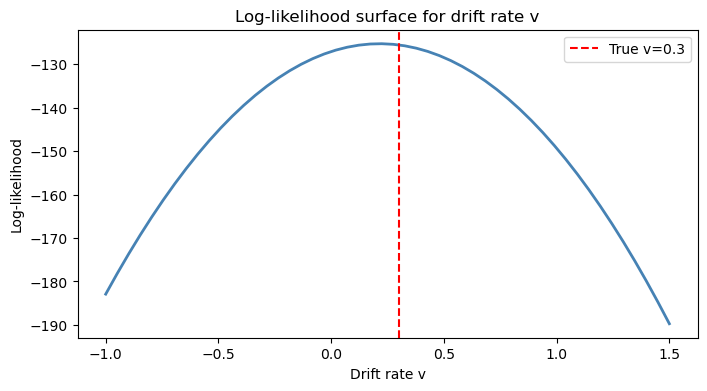

In [4]:
# Scan likelihood across a range of v values
# This shows you the likelihood surface for one parameter

v_range = np.linspace(-1.0, 1.5, 50)
log_liks = []

for v_test in v_range:
    ll = ddm_log_likelihood(data, v=v_test, a=1.2, z=0.5, t0=0.15)
    log_liks.append(ll)

plt.figure(figsize=(8, 4))
plt.plot(v_range, log_liks, color='steelblue', linewidth=2)
plt.axvline(x=0.3, color='red', linestyle='--', label='True v=0.3')
plt.xlabel('Drift rate v')
plt.ylabel('Log-likelihood')
plt.title('Log-likelihood surface for drift rate v')
plt.legend()
plt.show()